# Projet : Analyse du marché automobile américain

# 1. Importation des bibliothèques

In [281]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
#import seaborn as sns

plt.style.use("ggplot")

# 2. Chargement du dataset

In [282]:
df = pd.read_csv('car_prices.csv',sep = ',',  header = 0)

## Exploration des données

In [283]:
# Information générale sur le dataset
print("\nInformations générales sur le dataset :")
print("----------------------------------------------")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("----------------------------------------------")
print(f"La taille : {df.size}")
print("----------------------------------------------")
print(f"Le nom des colonnes : {list(df.columns)}")
print("----------------------------------------------")
print(f"\nInformations générales :")
print(df.info())
print("----------------------------------------------")
print("\nTypes de données :")
print(df.dtypes)


Informations générales sur le dataset :
----------------------------------------------
Nombre de lignes : 558837
Nombre de colonnes : 16
----------------------------------------------
La taille : 8941392
----------------------------------------------
Le nom des colonnes : ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']
----------------------------------------------

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833

In [284]:
# Afficher les premières lignes :
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [285]:
# Afficher les derniére lignes :
df.tail()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
558836,2014,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et2eke87277,ca,34.0,15008.0,gray,gray,ford motor credit company llc pd,29600.0,26700.0,Thu May 28 2015 05:30:00 GMT-0700 (PDT)


# Gestion des doublons

In [286]:
print(f"Le nombre des doublons est : {df.duplicated().sum()} ") 

Le nombre des doublons est : 0 


## Valeurs manquantes

In [287]:
print(f"Le nombre total des NAN est : {df.isna().sum().sum()} ")

Le nombre total des NAN est : 123376 


In [288]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing_values,
    'Pourcentage': missing_percentage
})
display(missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False))

Valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
transmission,65352,11.694287
body,13195,2.361154
condition,11820,2.115107
trim,10651,1.905922
model,10399,1.860829
make,10301,1.843292
color,749,0.134028
interior,749,0.134028
odometer,94,0.016821
mmr,38,0.006800


# Statistiques descriptives

## Données quantitatives

In [290]:
df[["condition", "odometer", "mmr", "sellingprice"]].describe().round(2)

,condition,odometer,mmr,sellingprice
count,547017.00,558743.00,558799.00,558825.00
mean,30.67,68320.02,13769.38,13611.36
std,13.40,53398.54,9679.97,9749.50
min,1.00,1.00,25.00,1.00
25%,23.00,28371.00,7100.00,6900.00
50%,35.00,52254.00,12250.00,12100.00
75%,42.00,99109.00,18300.00,18200.00
max,49.00,999999.00,182000.00,230000.00


# Graphiques pour detecter les outliers

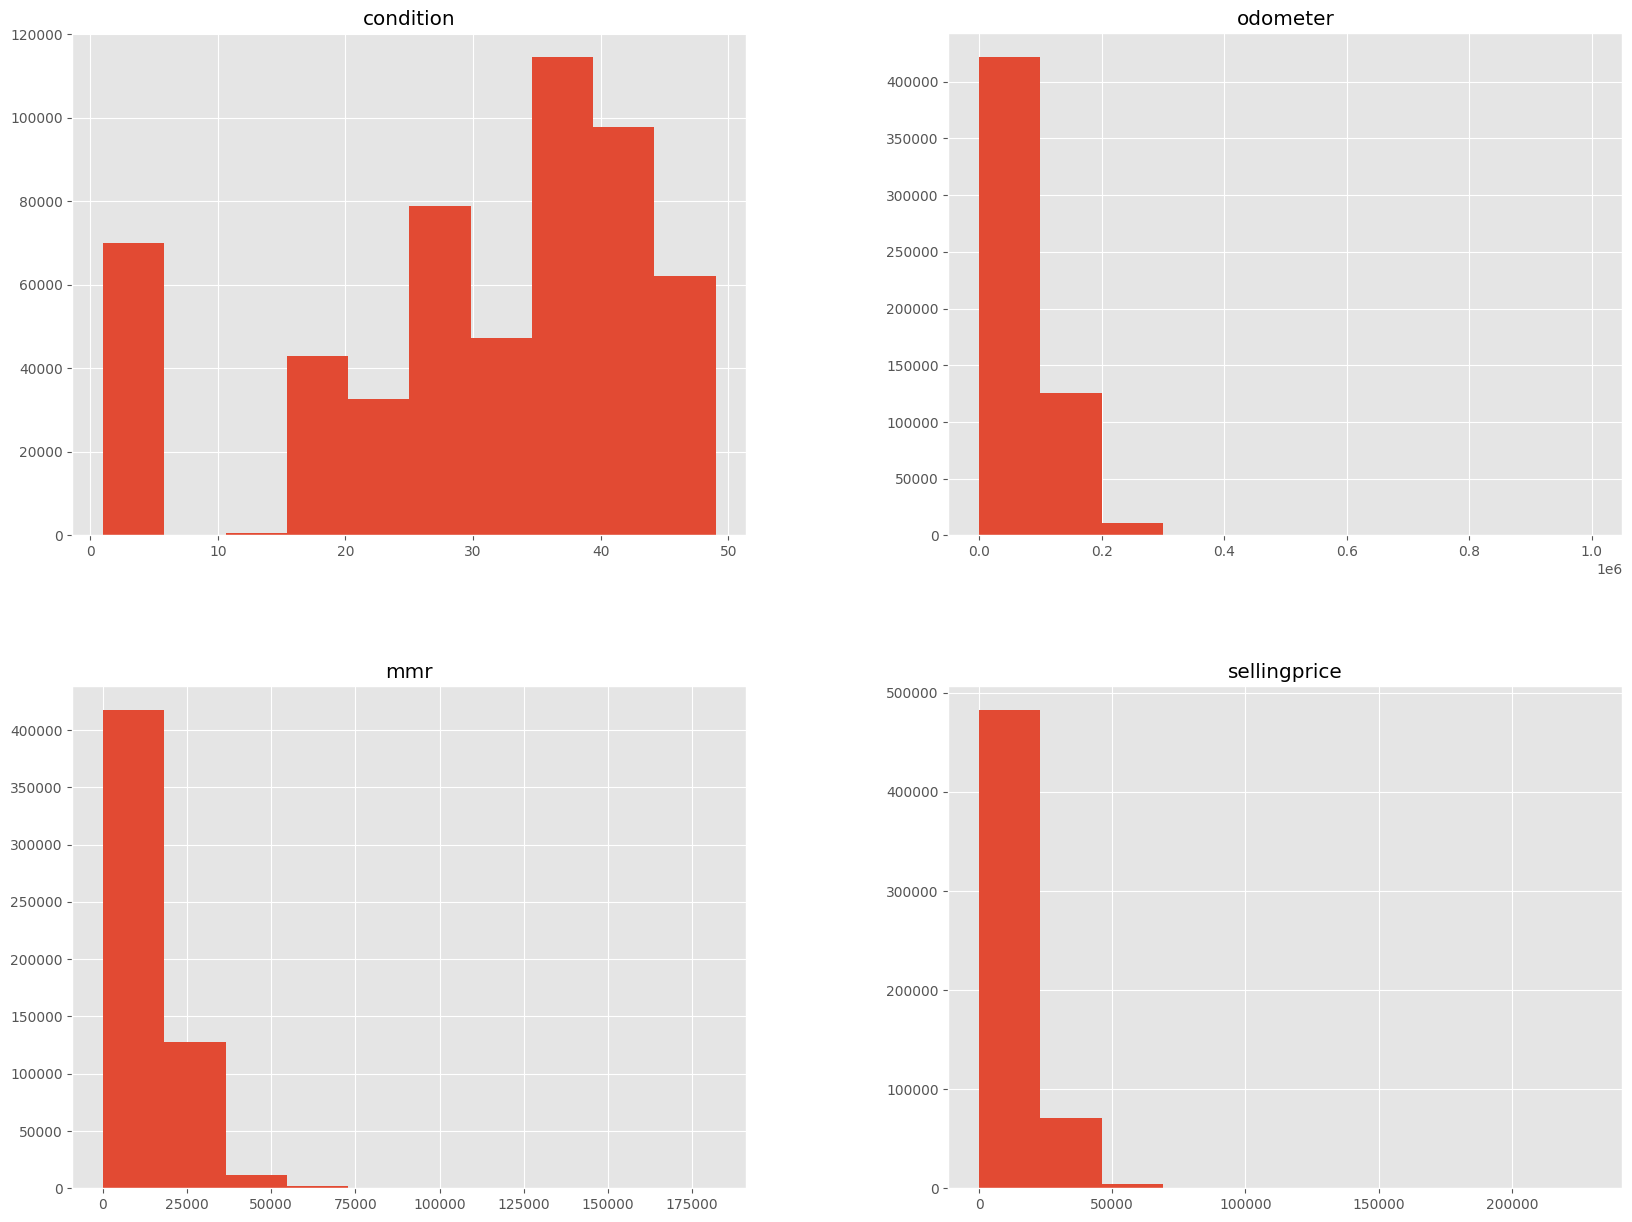

In [291]:
df[["condition", "odometer", "mmr", "sellingprice"]].hist(bins=10, figsize=(20,15))
plt.show()

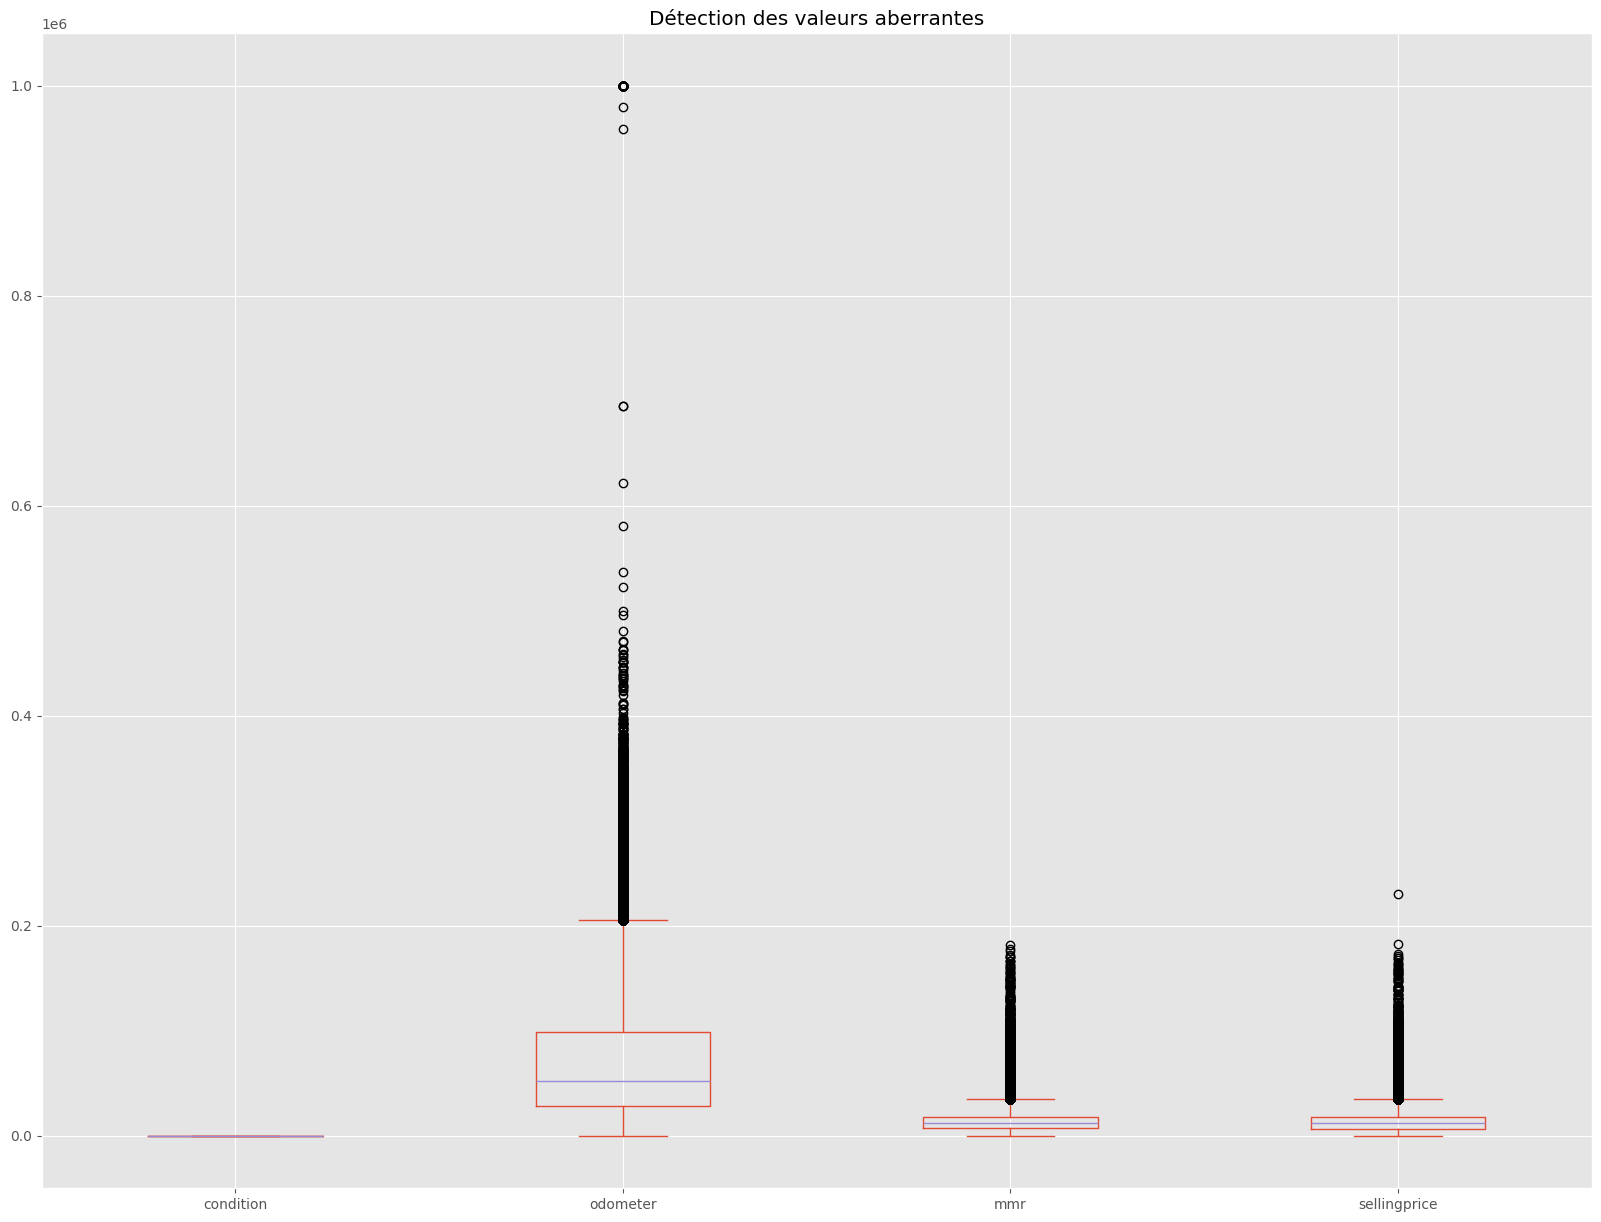

In [292]:
df[["condition", "odometer", "mmr", "sellingprice"]].plot(
    kind="box",
    figsize=(20, 15)
)

plt.title("Détection des valeurs aberrantes")
plt.show()

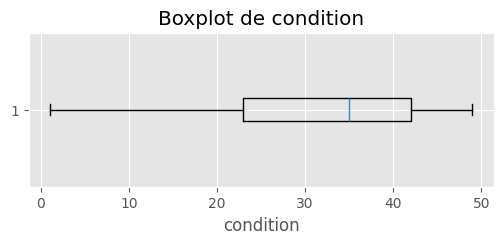

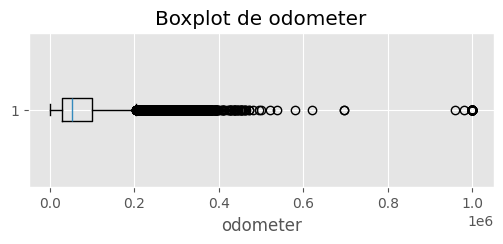

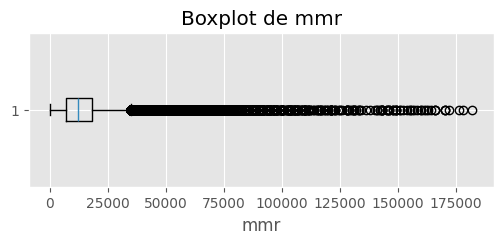

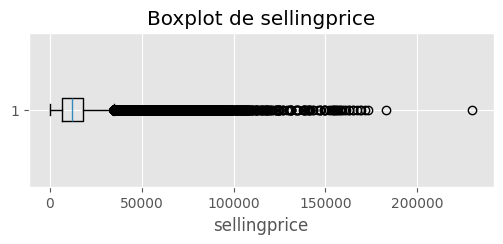

In [293]:
import matplotlib.pyplot as plt

colonnes = ["condition", "odometer", "mmr", "sellingprice"]

for col in colonnes:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

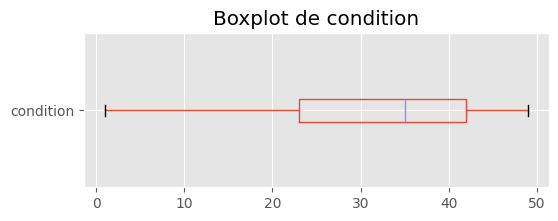

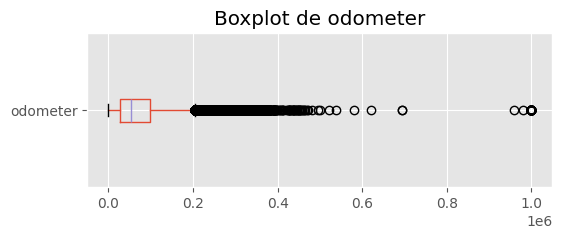

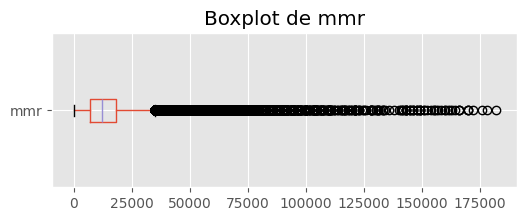

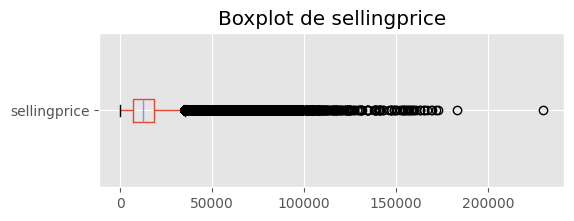

In [294]:
import matplotlib.pyplot as plt

colonnes = ["condition", "odometer", "mmr", "sellingprice"]

for col in colonnes:
    plt.figure(figsize=(6, 2))
    df.boxplot(column=col, vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

# Traitement des données manquantes

In [295]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
missing_values = df[["condition", "odometer", "mmr", "sellingprice"]].isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing_values,
    'Pourcentage': missing_percentage
})
display(missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False))

Valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
condition,11820,2.115107
odometer,94,0.016821
mmr,38,0.006800
sellingprice,12,0.002147


### Variable condition

In [296]:
df["condition"] = df["condition"].fillna(
    df["condition"].median()
)

### Variable odometer

In [297]:
df[df["odometer"] > 300000]["odometer"].count()

np.int64(744)

In [298]:
df[df["odometer"] > 300000]["odometer"].value_counts().head(20)

odometer
999999.0    72
303269.0     2
306175.0     2
694978.0     2
303326.0     2
309514.0     2
325682.0     2
311787.0     2
315411.0     1
316490.0     1
348070.0     1
381875.0     1
311164.0     1
355898.0     1
304319.0     1
423691.0     1
327237.0     1
347455.0     1
366136.0     1
378670.0     1
Name: count, dtype: int64

In [299]:
df["odometer"].sort_values(ascending=False).head(20)

361178    999999.0
485605    999999.0
13317     999999.0
489833    999999.0
417516    999999.0
163868    999999.0
83882     999999.0
117972    999999.0
476593    999999.0
136242    999999.0
117926    999999.0
451999    999999.0
191690    999999.0
485268    999999.0
59320     999999.0
240950    999999.0
385721    999999.0
290236    999999.0
501478    999999.0
260729    999999.0
Name: odometer, dtype: float64

In [300]:
seuils = [300000, 400000, 500000, 700000]

for seuil in seuils:
    nombre = (df["odometer"] > seuil).sum()
    pourcentage = nombre / len(df) * 100
    
    print(
        f"Plus de {seuil} km : {nombre} véhicules ({pourcentage:.3f}%)"
    )

Plus de 300000 km : 744 véhicules (0.133%)
Plus de 400000 km : 123 véhicules (0.022%)
Plus de 500000 km : 81 véhicules (0.014%)
Plus de 700000 km : 74 véhicules (0.013%)


In [301]:
df.loc[df["odometer"] == 999999, "odometer"] = np.nan

In [302]:
df["odometer"].isna().sum()

np.int64(166)

In [303]:
df["odometer"] = df["odometer"].fillna(
    df["odometer"].median()
)

In [304]:
df["odometer"].describe()

count    558837.000000
mean      68195.206762
std       52336.890863
min           1.000000
25%       28375.000000
50%       52247.000000
75%       99080.000000
max      980113.000000
Name: odometer, dtype: float64

### Variable mmr

In [305]:
df = df.dropna(subset=["mmr"])

### Variable sellingprice

In [306]:
df = df.dropna(subset=["sellingprice"])

## Statistiques descriptives(apres nettoyage)

In [307]:
df[["condition", "odometer", "mmr", "sellingprice"]].describe().round(2)

,condition,odometer,mmr,sellingprice
count,558799.00,558799.00,558799.00,558799.00
mean,30.76,68199.01,13769.38,13611.36
std,13.28,52336.41,9679.97,9749.73
min,1.00,1.00,25.00,1.00
25%,24.00,28378.00,7100.00,6900.00
50%,35.00,52247.00,12250.00,12100.00
75%,41.00,99083.00,18300.00,18200.00
max,49.00,980113.00,182000.00,230000.00


## Données qualitatives

In [308]:
df.describe(include=['object'])

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,548498,548400,548148,545604,493448,558799,558799,558050,558050,558799,558799
unique,96,973,1962,86,2,550284,38,20,17,14260,3745
top,Ford,Altima,Base,Sedan,automatic,wbanv13588cz57827,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,93553,19349,55815,199429,475904,5,82945,110969,244320,19693,5334


### make (Marque)

In [309]:
# Statistiques descriptives de make

print("Nombre de valeurs uniques :", df["make"].nunique())

print("\nValeur la plus fréquente (mode) :")
print(df["make"].mode()[0])

print("\nValeurs manquantes :")
print(df["make"].isna().sum())

print("\nTop 10 des marques :")
print(df["make"].value_counts().head(10))

Nombre de valeurs uniques : 96

Valeur la plus fréquente (mode) :
Ford

Valeurs manquantes :
10301

Top 10 des marques :
make
Ford         93553
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30708
Honda        27206
Hyundai      21811
BMW          20719
Kia          18075
Chrysler     17274
Name: count, dtype: int64


In [310]:
df["make"] = df["make"].fillna("Unknown")

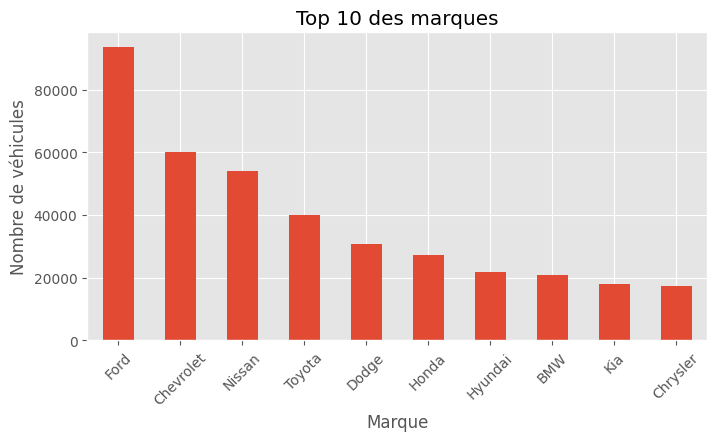

In [311]:
df["make"].value_counts().head(10).plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top 10 des marques")
plt.xlabel("Marque")
plt.ylabel("Nombre de véhicules")
plt.xticks(rotation=45)
plt.show()

### model (Modèle)

In [312]:
print("Nombre de modèles différents :", df["model"].nunique())

print("\nMode :")
print(df["model"].mode()[0])

print("\nValeurs manquantes :")
print(df["model"].isna().sum())

print("\nTop 10 modèles :")
print(df["model"].value_counts().head(10))

Nombre de modèles différents : 973

Mode :
Altima

Valeurs manquantes :
10399

Top 10 modèles :
model
Altima           19349
F-150            14479
Fusion           12945
Camry            12545
Escape           11861
Focus            10394
Accord            9127
3 Series          8204
Grand Caravan     7941
Impala            7923
Name: count, dtype: int64


In [313]:
df["model"] = df["model"].fillna("Unknown")

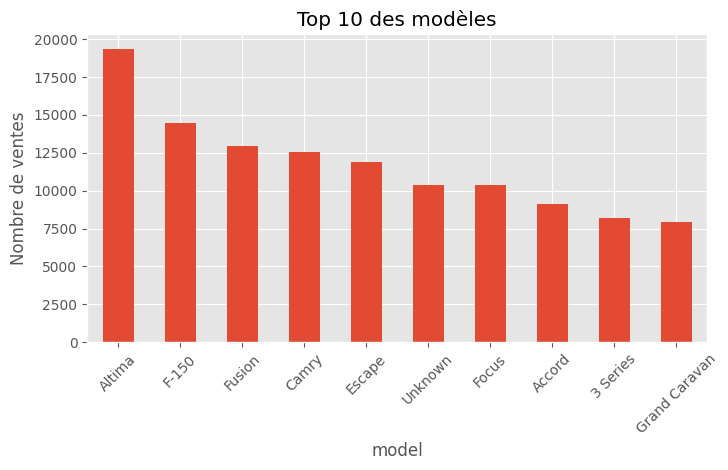

In [314]:
df["model"].value_counts().head(10).plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top 10 des modèles")
plt.ylabel("Nombre de ventes")
plt.xticks(rotation=45)
plt.show()

### body (Type de carrosserie)

In [315]:
print("Nombre de carrosseries :", df["body"].nunique())

print("\nMode :")
print(df["body"].mode()[0])

print("\nValeurs manquantes :")
print(df["body"].isna().sum())

print("\nRépartition :")
print(df["body"].value_counts())

Nombre de carrosseries : 86

Mode :
Sedan

Valeurs manquantes :
13195

Répartition :
body
Sedan          199429
SUV            119292
sedan           41903
suv             24552
Hatchback       21380
                ...  
Ram Van             1
CTS-V Wagon         1
g37 coupe           1
cab plus 4          1
cts wagon           1
Name: count, Length: 86, dtype: int64


In [316]:
# Normaliser les catégories
df["body"] = df["body"].str.lower()

# Traiter les valeurs manquantes
df["body"] = df["body"].fillna("unknown")

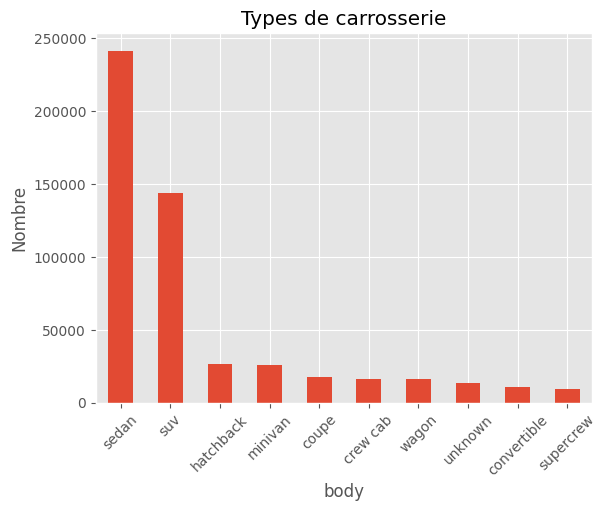

In [317]:
df["body"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Types de carrosserie")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.show()

### transmission

In [318]:
print("Nombre de transmissions :", df["transmission"].nunique())

print("\nMode :")
print(df["transmission"].mode()[0])

print("\nValeurs manquantes :")
print(df["transmission"].isna().sum())

print("\nRépartition :")
print(df["transmission"].value_counts(dropna=False))

Nombre de transmissions : 2

Mode :
automatic

Valeurs manquantes :
65351

Répartition :
transmission
automatic    475904
NaN           65351
manual        17544
Name: count, dtype: int64


In [319]:
# Corriger les erreurs de codage
df["transmission"] = df["transmission"].replace(
    ["sedan", "Sedan"],
    np.nan
)

# Garder l'information manquante
df["transmission"] = df["transmission"].fillna(
    "Unknown"
)

In [320]:
df["transmission"].value_counts(dropna=False)

transmission
automatic    475904
Unknown       65351
manual        17544
Name: count, dtype: int64

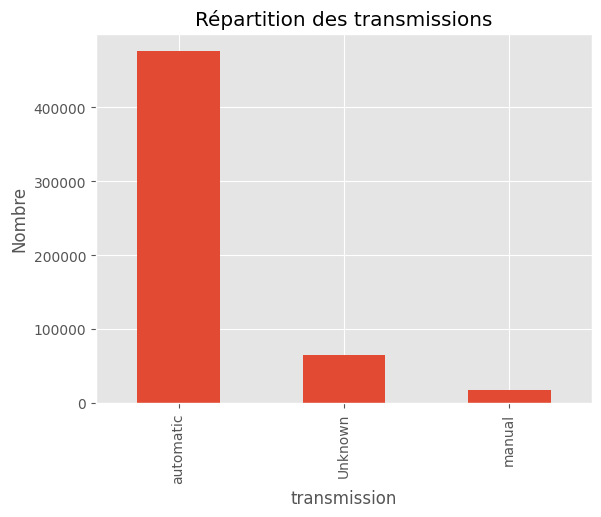

In [321]:
df["transmission"].value_counts(dropna=False).plot(
    kind="bar"
)

plt.title("Répartition des transmissions")
plt.ylabel("Nombre")
plt.show()

### state (État américain)

In [322]:
print("Nombre d'états :", df["state"].nunique())

print("\nMode :")
print(df["state"].mode()[0])

print("\nValeurs manquantes :")
print(df["state"].isna().sum())

print("\nTop 10 états :")
print(df["state"].value_counts().head(10))

Nombre d'états : 38

Mode :
fl

Valeurs manquantes :
0

Top 10 états :
state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23478
nc    21845
oh    21575
tn    20895
Name: count, dtype: int64


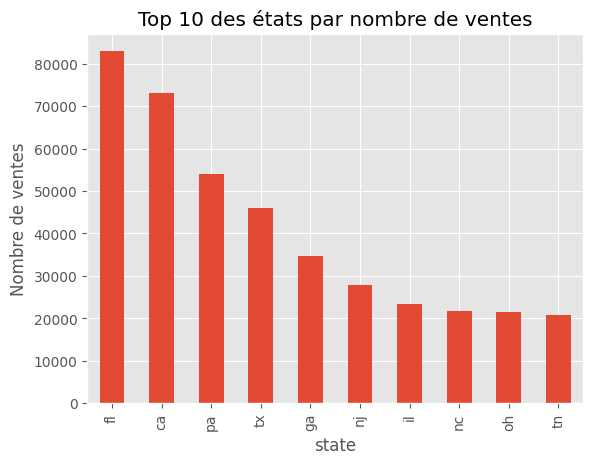

In [323]:
df["state"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 des états par nombre de ventes")
plt.ylabel("Nombre de ventes")
plt.show()

### color

In [324]:
print("Nombre de couleurs :", df["color"].nunique())

print("\nMode :")
print(df["color"].mode()[0])

print("\nValeurs manquantes :")
print(df["color"].isna().sum())

print("\nTop couleurs :")
print(df["color"].value_counts().head(20))

Nombre de couleurs : 20

Mode :
black

Valeurs manquantes :
749

Top couleurs :
color
black        110969
white        106670
silver        83385
gray          82854
blue          51138
red           43569
—             24685
green         11382
gold          11342
beige          9222
burgundy       8972
brown          6717
orange         2078
purple         1561
off-white      1449
yellow         1285
charcoal        479
turquoise       236
pink             42
lime             15
Name: count, dtype: int64


In [325]:
df["color"] = df["color"].replace(
    "—",
    np.nan
)


df["color"] = df["color"].fillna(
    "Unknown"
)

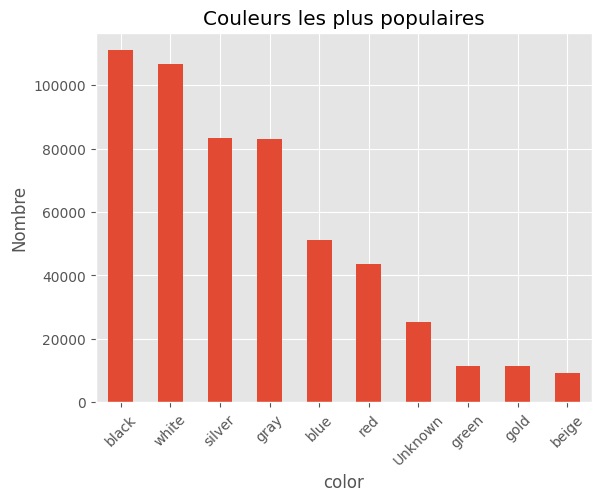

In [326]:
df["color"].value_counts().head(10).plot(
    kind="bar"
)
        
plt.title("Couleurs les plus populaires")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.show()

### interior

In [327]:
print("Nombre de couleurs intérieures :", df["interior"].nunique())

print("\nMode :")
print(df["interior"].mode()[0])

print("\nValeurs manquantes :")
print(df["interior"].isna().sum())

print("\nTop 10 intérieurs :")
print(df["interior"].value_counts().head(17))

Nombre de couleurs intérieures : 17

Mode :
black

Valeurs manquantes :
749

Top 10 intérieurs :
interior
black        244320
gray         178572
beige         59758
tan           44093
—             17075
brown          8640
red            1359
blue           1138
silver         1099
off-white       480
purple          339
gold            324
white           252
green           245
burgundy        191
orange          145
yellow           20
Name: count, dtype: int64


In [328]:
df["interior"] = df["interior"].replace(
    "—",
    np.nan
)

df["interior"] = df["interior"].fillna(
    "Unknown"
)

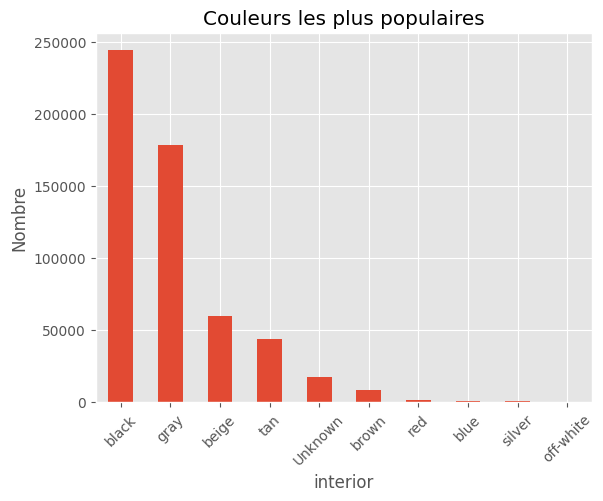

In [329]:
df["interior"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Couleurs les plus populaires")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.show()

### seller

In [330]:
print("Nombre de vendeurs :", df["seller"].nunique())

print("\nMode :")
print(df["seller"].mode()[0])

print("\nValeurs manquantes :")
print(df["seller"].isna().sum())

print("\nTop 10 vendeurs :")
print(df["seller"].value_counts().head(10))

Nombre de vendeurs : 14260

Mode :
nissan-infiniti lt

Valeurs manquantes :
0

Top 10 vendeurs :
seller
nissan-infiniti lt                       19693
ford motor credit company llc            19162
the hertz corporation                    18299
santander consumer                       15285
avis corporation                         12540
nissan infiniti lt                        9962
wells fargo dealer services               8796
tdaf remarketing                          7209
enterprise veh exchange/rental            6853
ge fleet services for itself/servicer     6692
Name: count, dtype: int64


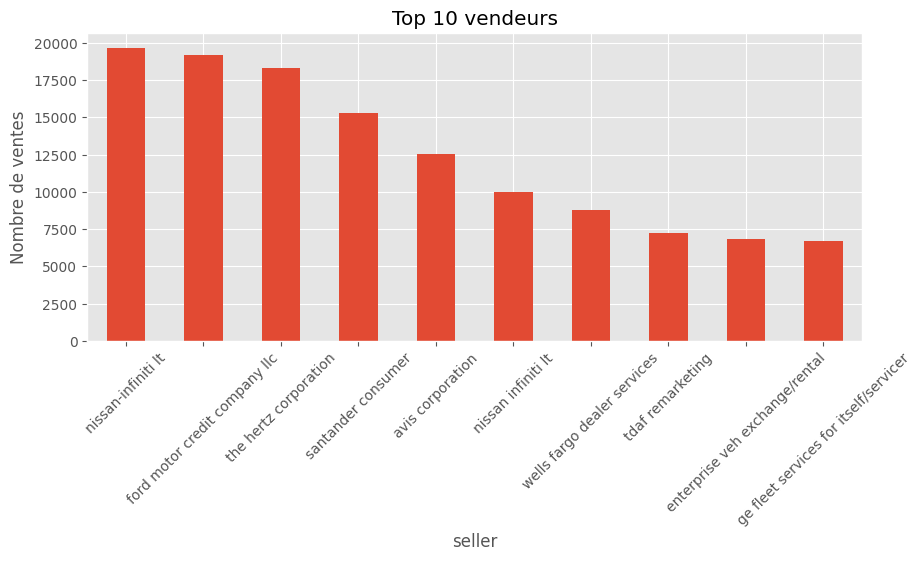

In [331]:
df["seller"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Top 10 vendeurs")
plt.ylabel("Nombre de ventes")
plt.xticks(rotation=45)
plt.show()

### vin

In [332]:
print("Nombre de VIN différents :", df["vin"].nunique())

print("Nombre total de lignes :", len(df))

print("Valeurs manquantes :", df["vin"].isna().sum())

Nombre de VIN différents : 550284
Nombre total de lignes : 558799
Valeurs manquantes : 0


# Questions d'analyse du marché automobile

## Question 1 : Quels facteurs influencent le prix de vente d'un véhicule ?

## 1.1 Relation entre kilométrage et prix de vente



Est-ce qu'un véhicule avec plus de kilomètres se vend moins cher ?

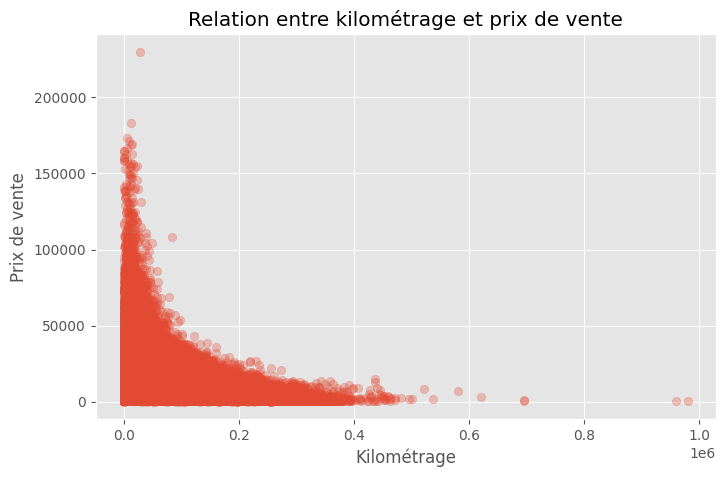

In [333]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["odometer"],
    df["sellingprice"],
    alpha=0.3
)

plt.title("Relation entre kilométrage et prix de vente")
plt.xlabel("Kilométrage")
plt.ylabel("Prix de vente")

plt.show()

## Question 2 : Le prix de vente est-il proche de la valeur du marché (MMR) ?

In [334]:
df["difference_prix"] = (
    df["sellingprice"] - df["mmr"]
)

In [335]:
df["difference_prix"].describe()

count    558799.000000
mean       -158.021199
std        1758.941195
min      -87750.000000
25%        -800.000000
50%         -50.000000
75%         650.000000
max      207200.000000
Name: difference_prix, dtype: float64

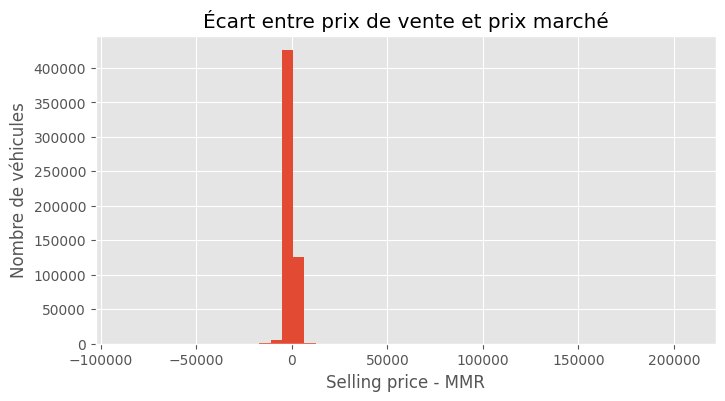

In [336]:
plt.figure(figsize=(8,4))

plt.hist(
    df["difference_prix"].dropna(),
    bins=50
)

plt.title("Écart entre prix de vente et prix marché")
plt.xlabel("Selling price - MMR")
plt.ylabel("Nombre de véhicules")

plt.show()

## Question 3 : Les véhicules en meilleur état se vendent-ils plus cher ?

In [337]:
prix_condition = (
    df.groupby("condition")["sellingprice"]
    .mean()
)

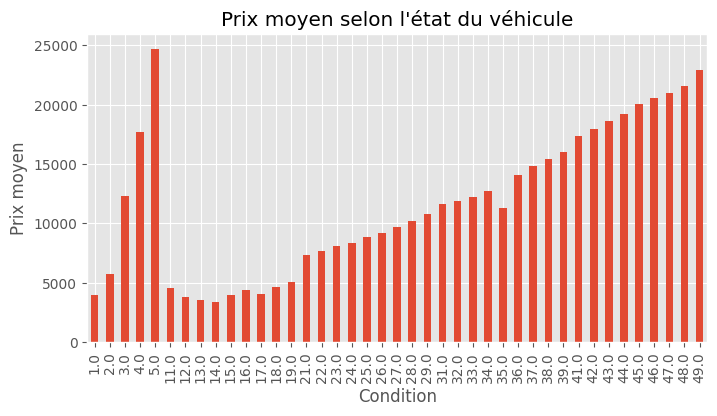

In [338]:
plt.figure(figsize=(8,4))

prix_condition.plot(
    kind="bar"
)

plt.title("Prix moyen selon l'état du véhicule")
plt.xlabel("Condition")
plt.ylabel("Prix moyen")

plt.show()

## Question 4 : Quel type de carrosserie est le plus rentable ?

In [339]:
prix_body = (
    df.groupby("body")["sellingprice"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

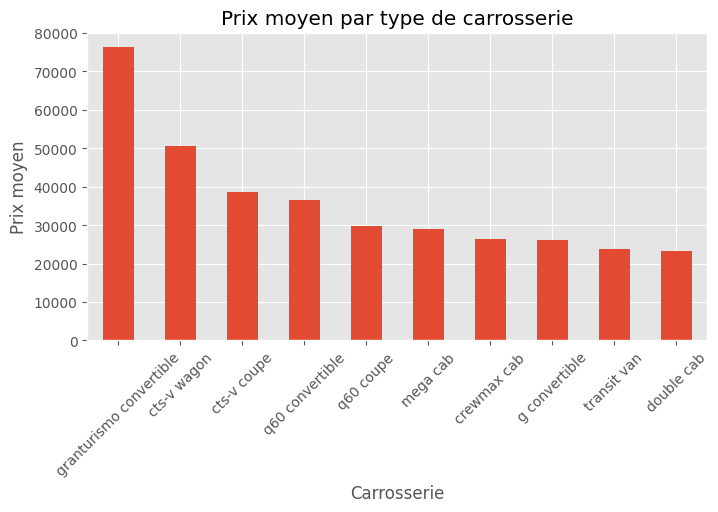

In [340]:
plt.figure(figsize=(8,4))

prix_body.plot(
    kind="bar"
)

plt.title("Prix moyen par type de carrosserie")
plt.xlabel("Carrosserie")
plt.ylabel("Prix moyen")

plt.xticks(rotation=45)

plt.show()

## Question 5 : Quelles marques ont la meilleure valeur de revente ?

In [343]:
prix_marque = (
    df.groupby("make")["sellingprice"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

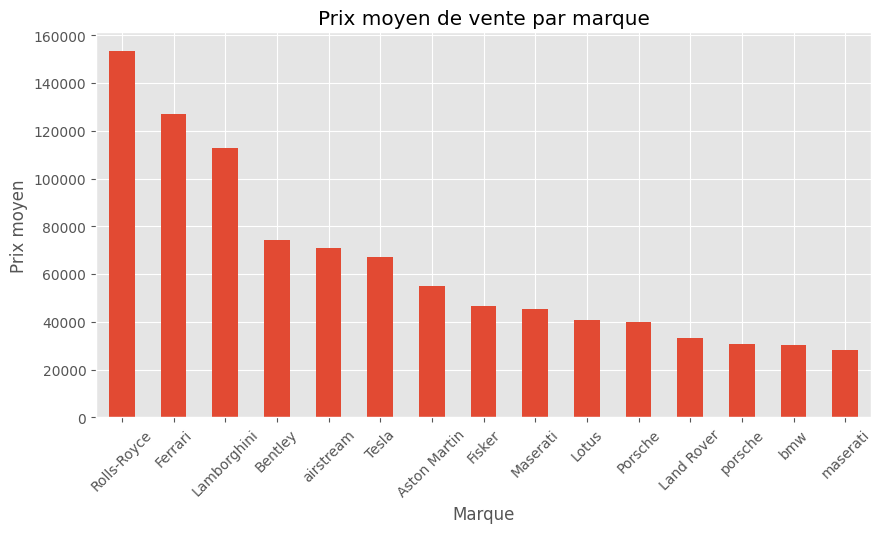

In [344]:
plt.figure(figsize=(10,5))

prix_marque.plot(
    kind="bar"
)

plt.title("Prix moyen de vente par marque")
plt.ylabel("Prix moyen")
plt.xlabel("Marque")

plt.xticks(rotation=45)

plt.show()

## Question 6 : Les transmissions influencent-elles le prix ?

In [345]:
prix_transmission = (
    df.groupby("transmission")["sellingprice"]
    .mean()
)

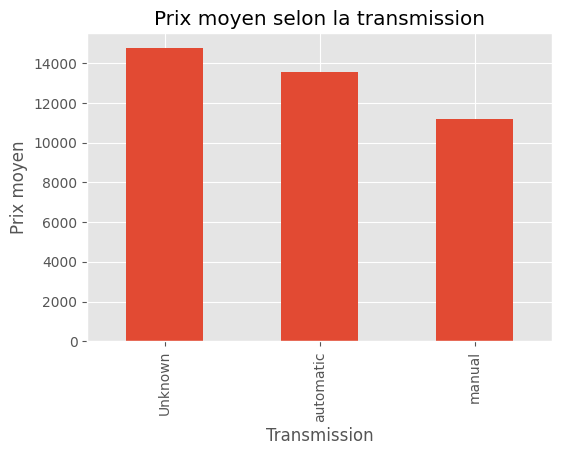

In [346]:
plt.figure(figsize=(6,4))

prix_transmission.plot(
    kind="bar"
)

plt.title("Prix moyen selon la transmission")
plt.xlabel("Transmission")
plt.ylabel("Prix moyen")

plt.show()

## Question 7 : Comment évolue le prix des véhicules selon l'année ?

In [348]:
prix_annee = (
    df.groupby("year")["sellingprice"]
    .mean()
)

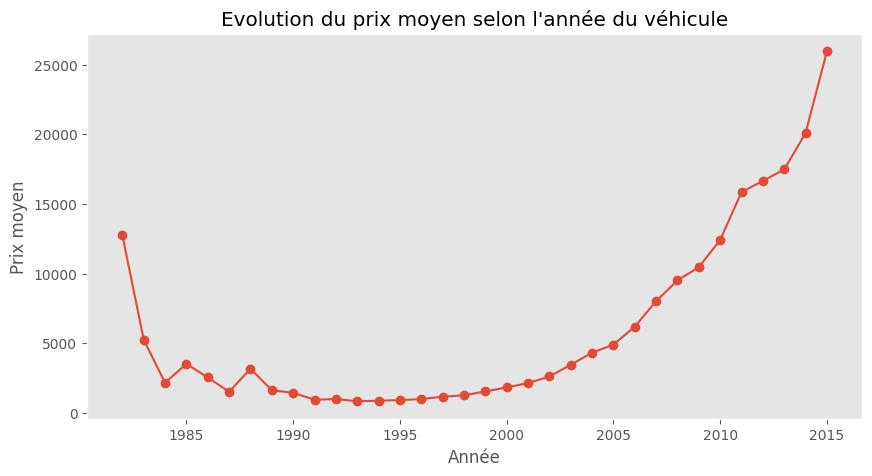

In [349]:
plt.figure(figsize=(10,5))

prix_annee.plot(
    kind="line",
    marker="o"
)

plt.title("Evolution du prix moyen selon l'année du véhicule")
plt.xlabel("Année")
plt.ylabel("Prix moyen")

plt.grid()

plt.show()

## Question 8 : Quels États ont les prix moyens les plus élevés ?

In [350]:
prix_state = (
    df.groupby("state")["sellingprice"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

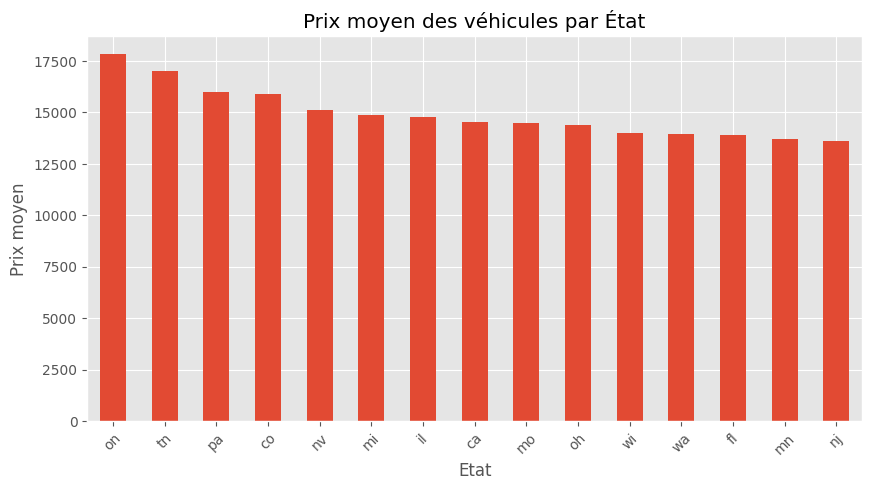

In [351]:
plt.figure(figsize=(10,5))

prix_state.plot(
    kind="bar"
)

plt.title("Prix moyen des véhicules par État")
plt.xlabel("Etat")
plt.ylabel("Prix moyen")

plt.xticks(rotation=45)

plt.show()

## Question 9 : Existe-t-il une relation entre MMR et prix final ?

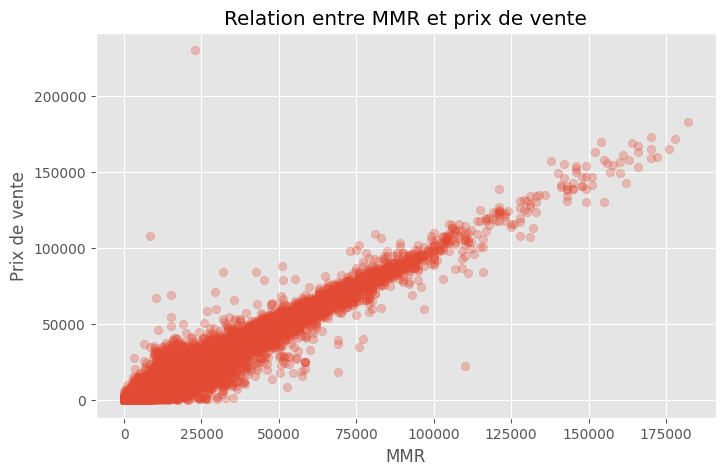

In [352]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["mmr"],
    df["sellingprice"],
    alpha=0.3
)

plt.title("Relation entre MMR et prix de vente")
plt.xlabel("MMR")
plt.ylabel("Prix de vente")

plt.show()

# Vérifier le contenu de saledate

In [353]:
df["saledate"].head()

0    Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1    Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2    Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3    Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4    Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
Name: saledate, dtype: object

In [364]:
# Conversion de la colonne saledate en datetime
def convert_date(date_str):
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

df['saledate'] = df['saledate'].apply(convert_date)

# Extraction d'informations temporelles
df['sale_month'] = df['saledate'].dt.month
df['sale_year'] = df['saledate'].dt.year
df['sale_day'] = df['saledate'].dt.day_name()

In [365]:
df["saledate"].dtype

datetime64[ns, tzoffset('PST', 28800)]

In [366]:
df["saledate"].isna().sum()

np.int64(163310)

In [367]:
df["saledate"].min()

Timestamp('2014-01-01 09:15:00+0800', tz='tzoffset('PST', 28800)')

In [368]:
df["saledate"].max()

Timestamp('2015-03-06 07:00:00+0800', tz='tzoffset('PST', 28800)')

In [369]:
df.loc[df["saledate"].isna(), "saledate"].head(20)

20     NaT
986    NaT
1506   NaT
2222   NaT
2699   NaT
2942   NaT
3090   NaT
3360   NaT
4306   NaT
4894   NaT
5436   NaT
5824   NaT
6364   NaT
7160   NaT
7750   NaT
7757   NaT
7826   NaT
7870   NaT
7873   NaT
7937   NaT
Name: saledate, dtype: datetime64[ns, tzoffset('PST', 28800)]

In [370]:
df["saledate"].info()

<class 'pandas.core.series.Series'>
Index: 558799 entries, 0 to 558836
Series name: saledate
Non-Null Count   Dtype                                 
--------------   -----                                 
395489 non-null  datetime64[ns, tzoffset('PST', 28800)]
dtypes: datetime64[ns, tzoffset('PST', 28800)](1)
memory usage: 8.5 MB
